Removing 2 highly correlated features

Accuracy: 0.9180327868852459

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.94      0.80      0.86        20
           2       1.00      1.00      1.00        15
           3       0.85      1.00      0.92        17
           4       0.75      0.75      0.75         4

    accuracy                           0.92        61
   macro avg       0.91      0.91      0.91        61
weighted avg       0.92      0.92      0.92        61



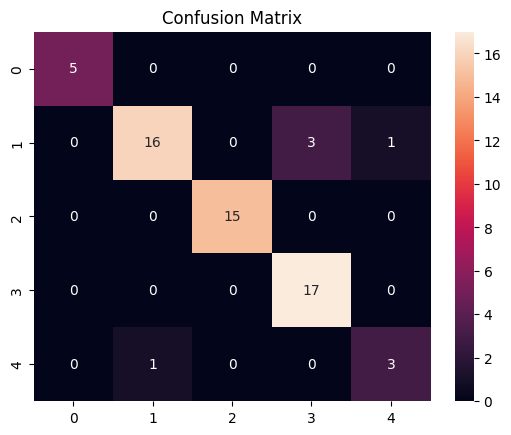

c:\Users\rosha\Documents\traffic_new\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


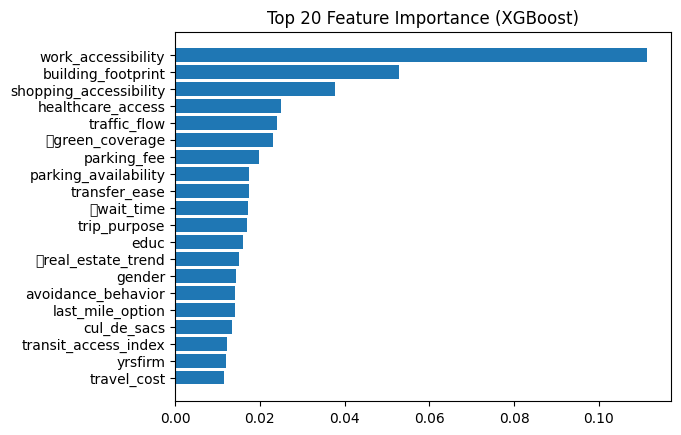


✅ Saved: feature_analysis.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("mode_choice_data.csv")

# =========================
# 2. SPLIT FEATURES / TARGET
# =========================
X = df.drop(columns=["travel_mode"])
y = df["travel_mode"]

# Fix labels for XGBoost (VERY IMPORTANT)
y = y - y.min()

# =========================
# 3. HANDLE MISSING VALUES
# =========================
X = X.fillna(X.median(numeric_only=True))

# =========================
# 4. REMOVE HIGHLY CORRELATED FEATURES
# =========================
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(f"Removing {len(to_drop)} highly correlated features")

X = X.drop(columns=to_drop)

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. TRAIN XGBOOST
# =========================
model = XGBClassifier(
    eval_metric="mlogloss",
    n_estimators=1000,
    max_depth=12,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# 7. EVALUATION
# =========================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# =========================
# 8. FEATURE IMPORTANCE (XGBoost)
# =========================
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Plot Top 20
plt.figure()
plt.barh(
    feature_importance_df["feature"][:20][::-1],
    feature_importance_df["importance"][:20][::-1]
)
plt.title("Top 20 Feature Importance (XGBoost)")
plt.show()

with pd.ExcelWriter("feature_analysis.xlsx") as writer:
    
    # XGBoost Feature Importance
    feature_importance_df.to_excel(
        writer, sheet_name="XGB Importance", index=False
    )
print("\n✅ Saved: feature_analysis.xlsx")